# 01 · Persecución del balón

**Alcance:** experimento tabular reproducible sobre un modelo cinemático acotado. Las dinámicas son aproximaciones didácticas; las curvas que produzca este notebook pertenecen al modelo local. La conexión con `rcssserver` se revisa por separado cuando Docker esté disponible.

Consulta `../docs/ball_pursuit.md` para el MDP, las simplificaciones y los criterios de éxito.


## 1. Estado, acciones y recompensa

El estado discreto usa **4 zonas de distancia × 4 sectores angulares** del balón respecto al jugador (16 estados). Las cuatro acciones son DASH 100, DASH 50 y giros de ±35°. El entorno aproxima cada DASH como un desplazamiento fijo, sin inercia. La recompensa es avance hacia el balón menos 0,2 por paso, con +100 al capturarlo a ≤0,8 m. Un episodio termina por captura, salida de la cancha o 40 pasos.

`reset()` inicia un episodio y `step(acción)` devuelve `(estado, recompensa, terminado, información)`. El estado contiene índices discretos; `información["success"]` identifica el criterio de éxito.


In [1]:
import sys
from pathlib import Path

# Funciona con el kernel del contenedor y con un kernel local de VS Code.
for candidate in (
    Path("/workspace/src"),
    Path.cwd() / "src",
    Path.cwd().parent / "src",
):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "No se encontró src/. Abre el notebook desde el repositorio o notebooks/."
    )

In [2]:
from metrics import summarize
from plotting import plot_training_comparison, plot_trajectory, plot_value_policy
from tabular import greedy_episode, train_q_learning
from tasks.ball_pursuit import BallPursuitEnv

## 2. Entrenamiento y exploración

`train_q_learning()` actualiza Q tras cada transición. Se ejecutan dos experimentos independientes con la misma semilla: ε fijo = 0,2 y ε decreciente desde 1,0 (factor 0,995; mínimo 0,05). Solo cambia la estrategia de exploración.


In [3]:
EPISODES = 1500
GAMMA = 0.99
ALPHA = 0.2
SEED = 42

experiments = {}
for label, mode, epsilon in (
    ("ε fijo", "constant", 0.2),
    ("ε decreciente", "decay", 1.0),
):
    env = BallPursuitEnv(seed=SEED)
    q, history = train_q_learning(
        env,
        episodes=EPISODES,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon_mode=mode,
        epsilon_start=epsilon,
        seed=SEED,
    )
    experiments[label] = (q, history)

## 3. Retorno, éxito y pasos

`G₀` es el retorno descontado calculado desde el primer paso. La tasa de éxito es el porcentaje de episodios que alcanzan el criterio de la tarea. Las curvas usan un promedio móvil de 50 episodios; el resumen usa los últimos 100.


ε fijo {'G0 medio': 47.86232800632369, 'Éxito (%)': 49.0, 'Pasos medios': 33.48}
ε decreciente {'G0 medio': 66.17029662498123, 'Éxito (%)': 68.0, 'Pasos medios': 30.54}


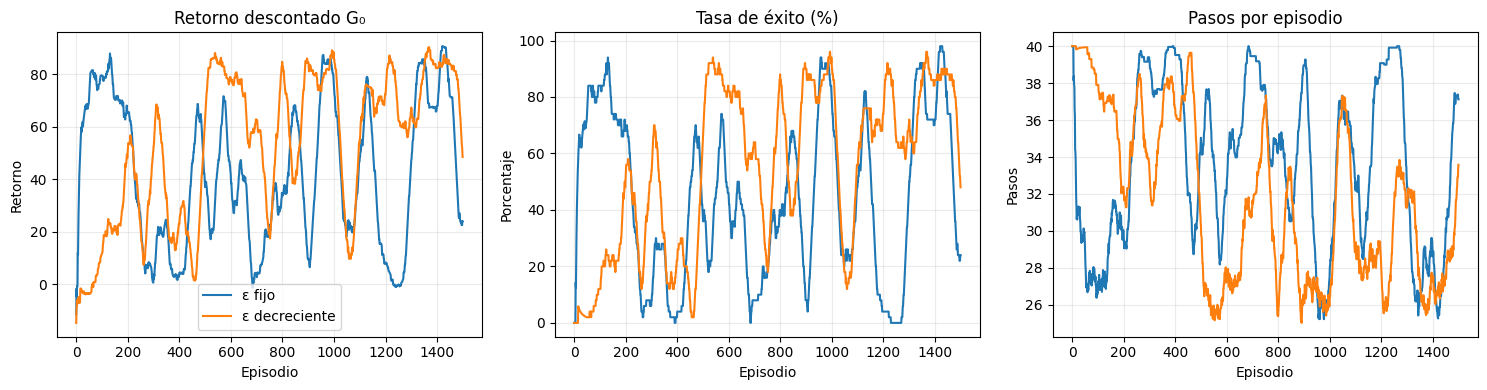

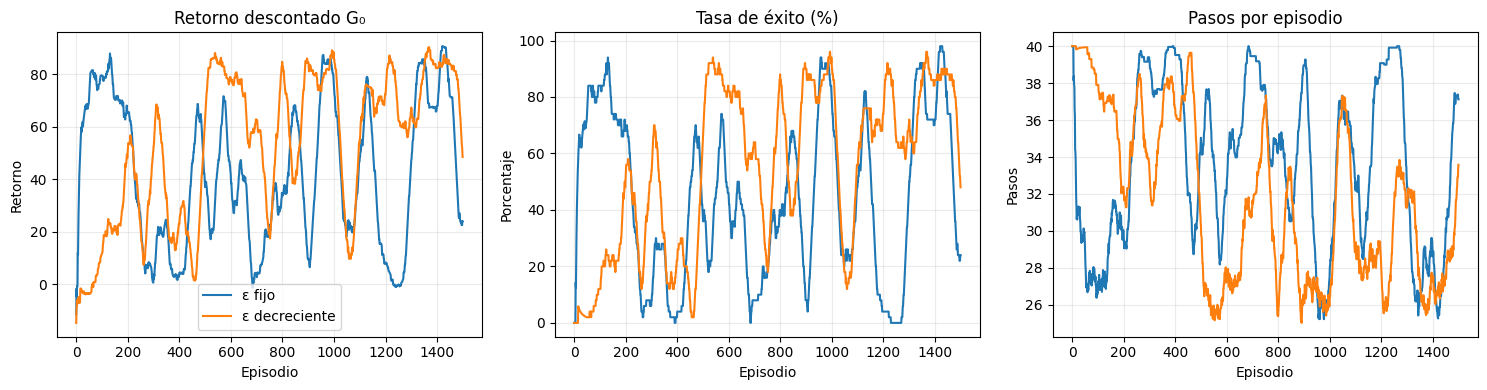

In [4]:
for label, (_, history) in experiments.items():
    print(label, summarize(history))
plot_training_comparison(
    {label: history for label, (_, history) in experiments.items()}
)

## 4. Valor, política y trayectoria

El mapa representa V estimado = max Q y la acción greedy estimada. En estados con más de dos componentes, las otras dimensiones se fijan en la combinación más frecuente entre los estados visitados. El blanco significa «sin visitas». Después se ejecuta un episodio sin exploración para dibujar su trayectoria.


{'success': False, 'distance': 48.325937399704884, 'angle': 131.44048304658963, 'steps': 38, 'reward_sum': -48.07846930572525}


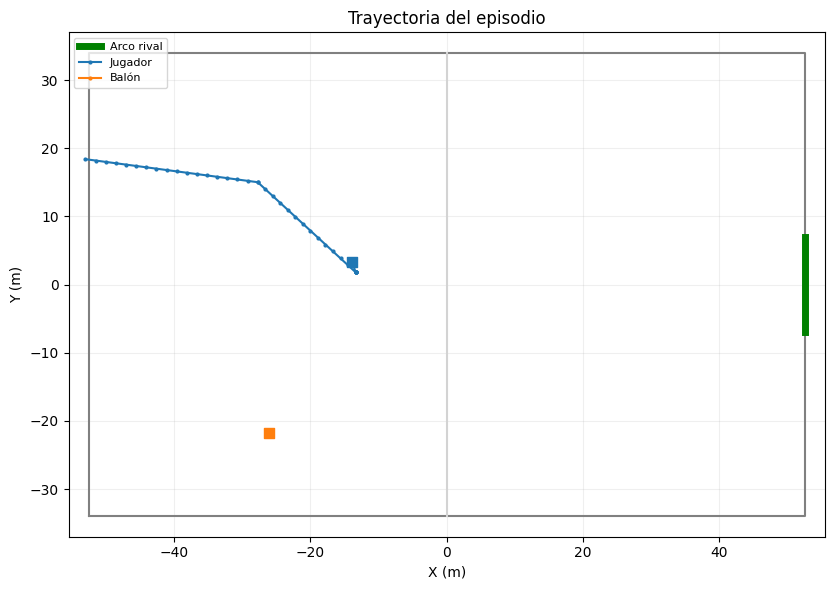

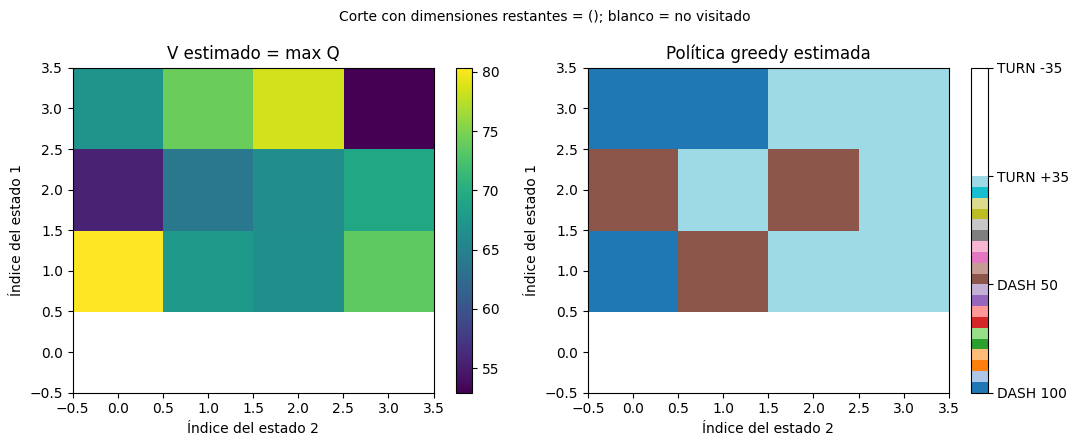

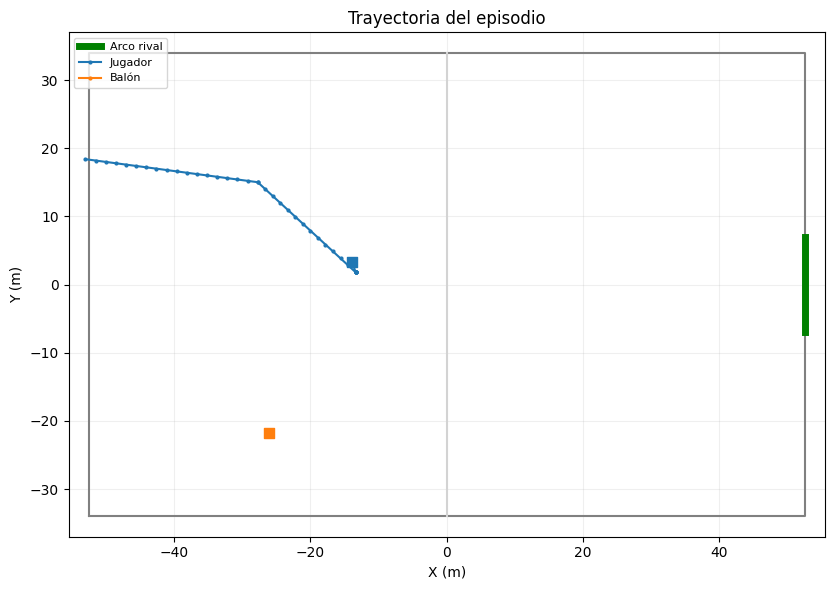

In [6]:
q_decay = experiments["ε decreciente"][0]
plot_value_policy(q_decay, BallPursuitEnv.state_shape, BallPursuitEnv.action_names)
evaluation_env = BallPursuitEnv(seed=2026)
print(greedy_episode(evaluation_env, q_decay))
plot_trajectory(evaluation_env)

## 5. Conexión opcional con `rcssserver`

Esta celda **no entrena** ni mide la política dentro de RoboCup. Sirve para comprobar los dos sockets y ubicar un balón mediante el trainer. Actívala cuando Docker termine de descargarse. El resultado del simulador local no constituye validación de desempeño en el servidor oficial.


In [ ]:
RUN_LIVE_PROBE = False  # cambia a True cuando los contenedores estén listos

if RUN_LIVE_PROBE:
    import os
    import time

    from robocup_client import RoboCup2DClient
    from trainer_client import TrainerClient

    host = os.getenv("SERVER_HOST", "127.0.0.1")
    player = RoboCup2DClient(
        host=host, port=int(os.getenv("SERVER_PORT", "6000")), team_name="Grupo02"
    )
    trainer = TrainerClient(host=host, port=int(os.getenv("TRAINER_PORT", "6001")))
    try:
        if not player.connect(init_pos=(-10.0, 0.0)):
            raise RuntimeError("No se conectó el jugador")
        print("Trainer:", trainer.connect())
        trainer.change_mode("before_kick_off")
        trainer.move_ball(0.0, 0.0)
        time.sleep(0.2)
        print("Observación RoboCup:", player.get_latest_observation())
    finally:
        trainer.close()
        player.close()